# Sense Padel Pondok Labu — Strategic Analysis
## Survival & Community Moat Framework

**Pertanyaan owner:** *"Gimana supaya Sense Padel nggak kena hype decay tapi punya community moat?"*

**Framework:**
1. **Isochrone Density** — padat atau tidak? → menentukan apakah butuh niche
2. **Review Analysis** — pasar jual experience atau service? ada sinyal sosial?
3. **Community Moat Score** — seberapa tinggi switching cost sosial?
4. **Strategic Recommendation** — community builder vs niche player

**Prereq:** Jalankan dulu:
```bash
python scrapper/scraper_gmaps_pondoklabu.py
python scrapper/scraper_reviews_pondoklabu.py
```

In [8]:
import sys
import math
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
OUT  = ROOT / 'output'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'font.family': 'sans-serif'})

BLUE  = '#3A86FF'
RED   = '#FF5A5F'
GREEN = '#06D6A0'
AMBER = '#FFB703'
GRAY  = '#8D99AE'
PURPLE= '#8338EC'

print('Setup OK')
print(f'ROOT: {ROOT}')

Setup OK
ROOT: /Users/muhammadfauzy/Documents/2.Data_Analyst/Padel Courts Analysis/Sense Padel


---
## Section 1: Isochrone Density Check
**Pertanyaan:** Seberapa padat kompetitor di radius 10-15 mnt dari Sense Padel?

- `dist_km ≤ 3` → 10 mnt berkendara (proxy isochrone)
- `dist_km ≤ 5` → 15 mnt berkendara

> Jika >5 court dalam 10 mnt → pasar MERAH → wajib niche strategy

In [9]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    a = math.sin((lat2-lat1)/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin((lon2-lon1)/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))


density_csv = OUT / 'padel_pondoklabu_density.csv'
courts_csv  = OUT / 'padel_pondoklabu.csv'

if density_csv.exists():
    df_courts = pd.read_csv(density_csv)
    print(f'Loaded: {density_csv.name}  ({len(df_courts)} courts)')
elif courts_csv.exists():
    df_courts = pd.read_csv(courts_csv)
    print(f'Loaded: {courts_csv.name}  ({len(df_courts)} courts)')
    print('[!] dist_km not available — computing from coordinates')
    SENSE_APPROX = (-6.2870, 106.7980)
    sense_rows = df_courts[df_courts['name'].str.contains('Sense', case=False, na=False)]
    if not sense_rows.empty:
        s_lat, s_lon = float(sense_rows.iloc[0]['lat']), float(sense_rows.iloc[0]['lon'])
    else:
        s_lat, s_lon = SENSE_APPROX
        print(f'  [!] Sense Padel not found, using approx: {SENSE_APPROX}')
    df_courts['dist_km'] = df_courts.apply(
        lambda r: haversine_km(s_lat, s_lon, float(r['lat']), float(r['lon']))
        if pd.notna(r.get('lat')) and pd.notna(r.get('lon')) else 999,
        axis=1
    )
else:
    raise FileNotFoundError('No court data found. Run scraper_gmaps_pondoklabu.py first.')

df_courts.head(3)

Loaded: padel_pondoklabu_density.csv  (142 courts)


,place_id,name,address,lat,lon,rating,review_count,phone,website,open_now,hours,types,_source_kelurahan,_source_keyword,_validated,dist_km,is_sense_padel,within_3km,within_5km
0,ChIJ__d2RQDvaS4RFUc5Ek5zTUQ,Sense Padel Margasatwa,"Jl. Margasatwa Raya No.59, RT.1/RW.3, Pd. Labu...",-6.313397,106.801925,4.8,49.0,0815-9926-681,https://www.bestpadel.com/sense-padel-margasatwa,True,['Monday: 6:00\u202fAM\u2009–\u20098:00\u202fP...,NaN,Pondok Labu,lapangan padel,True,0.000000,True,True,True
1,ChIJ_R5Oo-HvaS4Rn4vuZKuDrDw,three one three padel court,"Jl. Margasatwa Raya No.123 2, RT.4/RW.3, Pd. L...",-6.311899,106.803613,4.9,62.0,0813-1315-1912,NaN,True,['Monday: 6:00\u202fAM\u2009–\u200911:00\u202f...,NaN,Pondok Labu,lapangan padel,True,0.250073,False,True,True
2,ChIJlfvhGi3vaS4RznPRBzaUJYU,313 padel court,"Jl. Margasatwa Raya No.123 2, RT.4/RW.3, Pd. L...",-6.312107,106.803806,4.9,36.0,0813-1315-1912,NaN,True,['Monday: 6:00\u202fAM\u2009–\u200911:30\u202f...,NaN,Pondok Labu,lapangan padel,True,0.252556,False,True,True


In [10]:
sense_mask   = df_courts['name'].str.contains('Sense', case=False, na=False)
sense_row    = df_courts[sense_mask]
competitors  = df_courts[~sense_mask].copy()

n_3km  = (competitors['dist_km'] <= 3).sum()
n_5km  = (competitors['dist_km'] <= 5).sum()
n_10km = (competitors['dist_km'] <= 10).sum()

if n_3km > 6:
    density_color   = RED
    density_label   = 'MERAH — Sangat Padat'
    density_verdict = 'Margin akan tertekan. Wajib Niche Strategy atau Community Moat.'
elif n_3km >= 3:
    density_color   = AMBER
    density_label   = 'KUNING — Sedang'
    density_verdict = 'Persaingan ada tapi belum jenuh. Community Moat = kunci diferensiasi.'
else:
    density_color   = GREEN
    density_label   = 'HIJAU — Relatif Kosong'
    density_verdict = 'Peluang growth play terbuka. Bangun community sebelum kompetitor masuk.'

sep = '=' * 55
print('\n' + sep)
print('  DENSITY VERDICT')
print(sep)
print(f'  Competitor dalam 3km  (≈10 mnt): {n_3km}')
print(f'  Competitor dalam 5km  (≈15 mnt): {n_5km}')
print(f'  Competitor dalam 10km (≈20 mnt): {n_10km}')
print(f'  Status: {density_label}')
print(f'  Implikasi: {density_verdict}')


  DENSITY VERDICT
  Competitor dalam 3km  (≈10 mnt): 41
  Competitor dalam 5km  (≈15 mnt): 86
  Competitor dalam 10km (≈20 mnt): 140
  Status: MERAH — Sangat Padat
  Implikasi: Margin akan tertekan. Wajib Niche Strategy atau Community Moat.


In [ ]:
import os, json, math
import folium
from folium.plugins import HeatMap, MarkerCluster, Fullscreen
from dotenv import load_dotenv

load_dotenv(ROOT / '.env')
SENSE_LAT, SENSE_LON = -6.313397, 106.801925
SENSE_NAME = 'Sense Padel Margasatwa'

df_map    = df_courts.dropna(subset=['lat','lon']).copy()
df_map['lat']      = df_map['lat'].astype(float)
df_map['lon']      = df_map['lon'].astype(float)
df_map['rating_f'] = pd.to_numeric(df_map['rating'], errors='coerce').fillna(0)
df_map['is_sense'] = df_map['name'].str.contains('Sense', case=False, na=False)

with open(OUT / 'isochrones_pondoklabu.geojson') as f:
    iso_gj = json.load(f)

# ── Competitive density stats ──────────────────────────────────────────────────
def haversine(la1, lo1, la2, lo2):
    R = 6371
    dlt = (la2-la1)*math.pi/180; dlo = (lo2-lo1)*math.pi/180
    a = math.sin(dlt/2)**2 + math.cos(la1*math.pi/180)*math.cos(la2*math.pi/180)*math.sin(dlo/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

df_comp = df_map[~df_map['is_sense']].copy()
df_comp['dist_km'] = df_comp.apply(lambda r: haversine(SENSE_LAT, SENSE_LON, r.lat, r.lon), axis=1)
n_3km  = int((df_comp['dist_km'] <= 3).sum())
n_5km  = int((df_comp['dist_km'] <= 5).sum())
n_10km = int((df_comp['dist_km'] <= 10).sum())
nearest_name   = df_comp.nsmallest(1, 'dist_km').iloc[0]['name']
nearest_dist   = df_comp['dist_km'].min()
nearest_rating = df_comp.nsmallest(1, 'dist_km').iloc[0]['rating_f']

total_lapangan = len(df_map)
avg_rating     = round(df_map['rating_f'].replace(0, float('nan')).mean(), 2)
kel_col        = '_source_kelurahan' if '_source_kelurahan' in df_map.columns else None
n_kel          = df_map[kel_col].nunique() if kel_col else '—'
top5           = df_map[df_map['rating_f'] > 0].nlargest(5, 'rating_f')[['name','rating_f']]

# ── Color helpers ─────────────────────────────────────────────────────────────
def marker_color(r, is_sense):
    if is_sense:   return 'red'
    if r >= 4.7:   return 'darkblue'
    elif r >= 4.4: return 'blue'
    elif r >= 4.0: return 'cadetblue'
    elif r > 0:    return 'lightblue'
    else:          return 'gray'

def iso_color(is_sense):
    return '#C62828' if is_sense else '#1565C0'

# ── Map ───────────────────────────────────────────────────────────────────────
m = folium.Map(location=[SENSE_LAT, SENSE_LON], zoom_start=13,
               tiles='CartoDB positron', prefer_canvas=True, zoom_control=False)

# Layer 1 — Isochrone polygons (Sense on top)
iso_fg      = folium.FeatureGroup(name='Isochrone Coverage', show=True)
sense_feats = [f for f in iso_gj['features'] if f['properties'].get('is_sense')]
comp_feats  = [f for f in iso_gj['features'] if not f['properties'].get('is_sense')]

for feat in comp_feats + sense_feats:
    is_s   = feat['properties'].get('is_sense', False)
    name   = feat['properties'].get('name', '')
    rating = feat['properties'].get('rating', 0)
    c      = iso_color(is_s)
    tip    = f'<b>{name}</b> ⭐{rating:.1f}' if rating else f'<b>{name}</b>'
    folium.GeoJson(
        feat,
        style_function=lambda x, col=c, sense=is_s: {
            'fillColor': col, 'color': col,
            'weight':       3.0 if sense else 0.5,
            'fillOpacity':  0.22 if sense else 0.04,
            'dashArray':    '' if sense else '3,3',
        },
        tooltip=tip
    ).add_to(iso_fg)
iso_fg.add_to(m)

# Layer 2 — Heatmap (on by default for storytelling)
heat_fg = folium.FeatureGroup(name='Density Heatmap', show=True)
HeatMap(
    [[r.lat, r.lon, float(r.rating_f) if r.rating_f > 0 else 3.0] for _, r in df_map.iterrows()],
    min_opacity=0.3, radius=40, blur=30, max_zoom=14,
    gradient={'0.0': '#0f0c29', '0.4': '#1565C0', '0.7': '#FFD700', '1.0': '#C62828'}
).add_to(heat_fg)
heat_fg.add_to(m)

# Layer 3 — Markers with cluster
court_fg = folium.FeatureGroup(name='Lapangan Padel', show=True)
cluster  = MarkerCluster(
    options={'maxClusterRadius': 40, 'disableClusteringAtZoom': 15}
).add_to(court_fg)

for _, row in df_map.iterrows():
    r_val = float(row['rating_f'])
    is_s  = bool(row['is_sense'])
    col   = marker_color(r_val, is_s)
    r_str = f'{r_val:.1f}' if r_val > 0 else '—'
    badge = '#C62828' if is_s else '#1565C0'
    popup_html = (
        '<div style="font-family:\'Helvetica Neue\',sans-serif;min-width:220px;'
        'font-size:13px;padding:4px">'
        f'<div style="font-weight:700;font-size:15px;margin-bottom:6px">{row["name"]}</div>'
        f'<div style="margin-bottom:8px"><span style="background:{badge};color:white;'
        'padding:2px 8px;border-radius:20px;font-weight:700;font-size:13px">'
        f'⭐ {r_str}</span></div>'
        f'<a href="https://www.google.com/maps/dir/?api=1&destination={row.lat},{row.lon}"'
        ' target="_blank" style="background:#1a1a2e;color:white;padding:5px 12px;'
        'border-radius:6px;text-decoration:none;font-size:12px;font-weight:600">'
        '🧭 Directions</a></div>'
    )
    folium.Marker(
        [row.lat, row.lon],
        icon=folium.Icon(color=col, icon='star' if is_s else 'circle', prefix='fa'),
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f'{"⭐"+r_str if r_val > 0 else "?"} {row["name"]}',
    ).add_to(cluster)
court_fg.add_to(m)

# Layer 4 — Kelurahan labels
kel_fg  = folium.FeatureGroup(name='Kelurahan Labels', show=True)
kel_csv = OUT / 'kelurahan_geocoded_pondoklabu.csv'
if kel_csv.exists():
    df_kel = pd.read_csv(kel_csv)
    for _, k in df_kel.iterrows():
        if pd.isna(k.get('lat')) or pd.isna(k.get('lon')): continue
        kel_name = str(k.get('kelurahan', k.get('name', '')))
        count    = int(df_map[df_map[kel_col] == kel_name].shape[0]) if kel_col else 0
        if count == 0: continue
        folium.Marker(
            [float(k['lat']), float(k['lon'])],
            icon=folium.DivIcon(
                html=(
                    '<div style="font-family:\'Helvetica Neue\',sans-serif;'
                    'font-size:10px;font-weight:700;color:#1a1a2e;'
                    'background:rgba(255,255,255,0.9);border:1.5px solid #1565C0;'
                    'border-radius:4px;padding:2px 6px;white-space:nowrap;'
                    f'box-shadow:0 1px 4px rgba(0,0,0,0.12)">'
                    f'{kel_name} '
                    f'<span style="font-weight:400;color:#777;font-size:9px">{count}</span>'
                    '</div>'
                ),
                icon_size=(130, 28), icon_anchor=(65, 14)
            )
        ).add_to(kel_fg)
kel_fg.add_to(m)

# Layer control at bottomleft, fullscreen at topright
folium.LayerControl(collapsed=True, position='bottomleft').add_to(m)
Fullscreen(position='topright').add_to(m)

# ── Sense Padel story callout annotation ─────────────────────────────────────
# Floating label near Sense Padel to anchor the narrative
callout_html = (
    '<div style="font-family:\'Helvetica Neue\',sans-serif;'
    'background:rgba(198,40,40,0.92);color:white;'
    'padding:5px 10px;border-radius:20px;font-size:11px;font-weight:700;'
    'white-space:nowrap;box-shadow:0 2px 8px rgba(0,0,0,0.3);'
    'border:2px solid white;">'
    f'← {n_3km} kompetitor dalam 10 mnt'
    '</div>'
)
folium.Marker(
    [SENSE_LAT + 0.012, SENSE_LON - 0.03],
    icon=folium.DivIcon(html=callout_html, icon_size=(210, 30), icon_anchor=(0, 15))
).add_to(m)

# ── Main panel (top-left, Bintaro v2 style + insight section) ─────────────────
top5_rows = ''.join(
    f'<tr><td style="padding:2px 6px">⭐ {r.rating_f:.1f}</td>'
    f'<td style="padding:2px 6px;color:#555">{r["name"][:25]}</td></tr>'
    for _, r in top5.iterrows()
)

# Density bar: 3 segments
def density_bar(n, max_n, color):
    pct = min(n / max_n * 100, 100)
    return (
        f'<div style="background:#f0f0f0;border-radius:3px;height:6px;margin-top:3px">'
        f'<div style="background:{color};width:{pct:.0f}%;height:6px;border-radius:3px"></div>'
        f'</div>'
    )

panel_html = (
    '<div id="main-panel" style="position:fixed;top:15px;left:15px;z-index:9999;'
    'background:white;border-radius:10px;'
    'box-shadow:0 4px 16px rgba(0,0,0,0.15);'
    'font-family:\'Helvetica Neue\',sans-serif;width:250px;overflow:hidden">'

    # Header
    '<div style="background:#1a1a2e;color:white;padding:12px 16px">'
    f'<div style="font-size:16px;font-weight:700">🎾 {SENSE_NAME}</div>'
    '<div style="font-size:11px;opacity:0.7;margin-top:2px">Competitive Density — 10 min drive</div>'
    '</div>'

    # Stats
    '<div style="padding:10px 16px;border-bottom:1px solid #f0f0f0">'
    '<table style="width:100%;font-size:12px;border-collapse:collapse">'
    f'<tr><td>🏟️ Total lapangan</td><td style="text-align:right;font-weight:700">{total_lapangan}</td></tr>'
    f'<tr><td>⭐ Avg rating</td><td style="text-align:right;font-weight:700">{avg_rating}</td></tr>'
    f'<tr><td>🏘️ Kelurahan</td><td style="text-align:right;font-weight:700;color:#1565C0">{n_kel}</td></tr>'
    '</table></div>'

    # Competitive density section (the key story)
    '<div style="padding:10px 16px;border-bottom:1px solid #f0f0f0;background:#fff8f8">'
    '<div style="font-size:11px;font-weight:700;color:#C62828;margin-bottom:8px;'
    'letter-spacing:0.4px">⚠️ COMPETITIVE DENSITY</div>'
    '<div style="font-size:12px;color:#333;margin-bottom:5px">'
    f'<b style="font-size:18px;color:#C62828">{n_3km}</b>'
    ' lapangan dalam <b>3 km</b>'
    f'{density_bar(n_3km, 60, "#C62828")}</div>'
    '<div style="font-size:12px;color:#333;margin-bottom:5px">'
    f'<b style="font-size:15px;color:#E57373">{n_5km}</b>'
    ' lapangan dalam <b>5 km</b>'
    f'{density_bar(n_5km, 100, "#E57373")}</div>'
    '<div style="font-size:12px;color:#333;margin-bottom:8px">'
    f'<b style="font-size:13px;color:#888">{n_10km}</b>'
    ' lapangan dalam <b>10 km</b>'
    f'{density_bar(n_10km, 150, "#ccc")}</div>'
    '<div style="background:#C62828;color:white;border-radius:5px;'
    'padding:5px 10px;font-size:11px;font-weight:700;text-align:center">'
    '🔴 STATUS: MERAH — Sangat Padat'
    '</div></div>'

    # Strategic insight
    '<div style="padding:10px 16px;border-bottom:1px solid #f0f0f0;background:#f0f8ff">'
    '<div style="font-size:11px;font-weight:700;color:#1565C0;margin-bottom:6px;'
    'letter-spacing:0.4px">💡 STRATEGI</div>'
    '<div style="font-size:11px;color:#333;line-height:1.5">'
    '→ <b>Beginner Academy</b> — gap score 2.4, 0 kompetitor<br>'
    '→ <b>Liga Internal</b> — switching cost emosional<br>'
    '→ <b>Community moat</b> sebelum hype decay'
    '</div></div>'

    # Marker legend
    '<div style="padding:10px 16px;border-bottom:1px solid #f0f0f0">'
    '<div style="font-size:11px;font-weight:700;color:#888;margin-bottom:6px">MARKER = RATING</div>'
    '<div style="font-size:11px;">'
    '🔴 Merah &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Sense Padel<br>'
    '🔵 Biru tua &nbsp;&nbsp;&nbsp;&nbsp;≥ 4.7<br>'
    '🔵 Biru &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;≥ 4.4<br>'
    '🔵 Cadet blue &nbsp;≥ 4.0<br>'
    '🔵 Light blue &nbsp;&lt; 4.0<br>'
    '⚫ Abu &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;No rating'
    '</div></div>'

    # Top 5
    '<div style="padding:10px 16px">'
    '<div style="font-size:11px;font-weight:700;color:#888;margin-bottom:6px">TOP 5 RATING</div>'
    f'<table style="font-size:11px;width:100%">{top5_rows}</table>'
    '</div>'

    '</div>'  # end panel
)

m.get_root().html.add_child(folium.Element(panel_html))

out_html = OUT / 'isochrone_map_pondoklabu.html'
m.save(str(out_html))
print(f'Saved → {out_html}  ({out_html.stat().st_size // 1024} KB)')


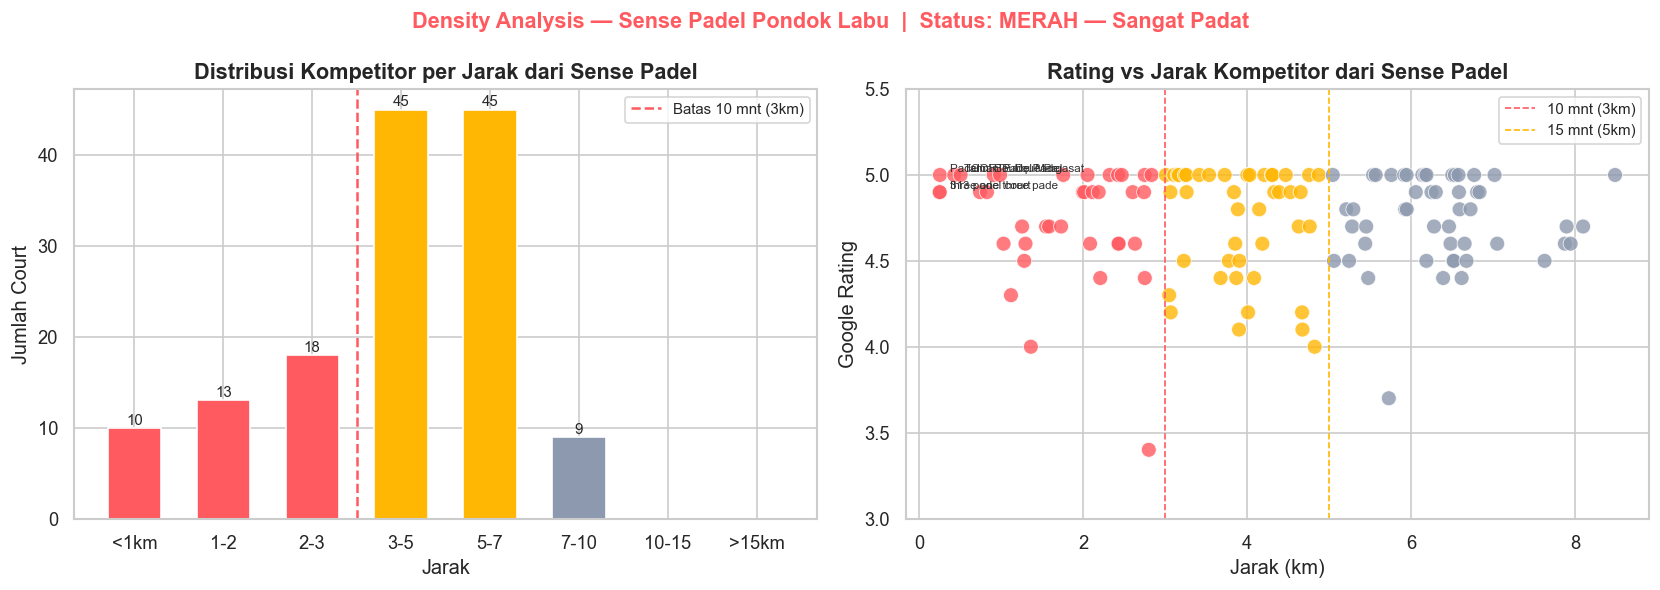


Top 5 kompetitor terdekat:
                        name  dist_km  rating  review_count
 three one three padel court 0.250073     4.9          62.0
             313 padel court 0.252556     4.9          36.0
Padelin' Boutique Padel Club 0.254931     5.0           1.0
      Taman Padel Margasatwa 0.429667     5.0           1.0
              CORTE De Padel 0.506627     5.0           1.0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distance distribution
ax1 = axes[0]
bins = [0, 1, 2, 3, 5, 7, 10, 15, 100]
labels = ['<1km', '1-2', '2-3', '3-5', '5-7', '7-10', '10-15', '>15km']
competitors['dist_bin'] = pd.cut(competitors['dist_km'], bins=bins, labels=labels)
dist_counts = competitors['dist_bin'].value_counts().sort_index()
colors_bar = [RED if label in ['<1km','1-2','2-3'] else AMBER if label in ['3-5','5-7'] else GRAY for label in dist_counts.index]
bars = ax1.bar(dist_counts.index, dist_counts.values, color=colors_bar, edgecolor='white', width=0.6)
ax1.set_title('Distribusi Kompetitor per Jarak dari Sense Padel', fontweight='bold')
ax1.set_xlabel('Jarak')
ax1.set_ylabel('Jumlah Court')
ax1.axvline(x=2.5, color=RED, linestyle='--', linewidth=1.5, label='Batas 10 mnt (3km)')
ax1.legend(fontsize=9)
for bar in bars:
    if bar.get_height() > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

# Plot 2: Rating vs Distance scatter
ax2 = axes[1]
comp_clean = competitors.dropna(subset=['rating', 'dist_km'])
scatter_colors = [RED if d <= 3 else AMBER if d <= 5 else GRAY for d in comp_clean['dist_km']]
sc = ax2.scatter(comp_clean['dist_km'], comp_clean['rating'],
                 c=scatter_colors, s=80, alpha=0.8, edgecolors='white', linewidth=0.5)
ax2.axvline(x=3, color=RED, linestyle='--', linewidth=1, label='10 mnt (3km)')
ax2.axvline(x=5, color=AMBER, linestyle='--', linewidth=1, label='15 mnt (5km)')
ax2.set_title('Rating vs Jarak Kompetitor dari Sense Padel', fontweight='bold')
ax2.set_xlabel('Jarak (km)')
ax2.set_ylabel('Google Rating')
ax2.set_ylim(3, 5.5)
ax2.legend(fontsize=9)

# Annotate closest competitors
for _, row in comp_clean.sort_values('dist_km').head(5).iterrows():
    ax2.annotate(row['name'][:20], (row['dist_km'], row['rating']),
                 textcoords='offset points', xytext=(6, 2), fontsize=7, color='#333')

fig.suptitle(f'Density Analysis — Sense Padel Pondok Labu  |  Status: {density_label}',
             fontsize=13, fontweight='bold', color=density_color)
plt.tight_layout()
plt.show()

print(f'\nTop 5 kompetitor terdekat:')
print(competitors.sort_values('dist_km')[['name','dist_km','rating','review_count']].head(5).to_string(index=False))

---
## Section 2: Review Sentiment & Classification
**Pertanyaan:** Apa yang sebenarnya dibeli orang? Infrastruktur atau Experience?

**Tiga dimensi yang dianalisis:**
- `Experience` — review tentang lapangan, fasilitas, kebersihan
- `Service` — review tentang staf, booking, harga, responsivitas
- `Social` — sinyal komunitas: ada yang nyebut teman baru, liga, turnamen?

In [12]:
reviews_csv = OUT / 'reviews_pondoklabu.csv'
summary_csv = OUT / 'review_summary_pondoklabu.csv'

if not reviews_csv.exists():
    raise FileNotFoundError('reviews_pondoklabu.csv not found. Run scraper_reviews_pondoklabu.py first.')

df_rev = pd.read_csv(reviews_csv)
df_sum = pd.read_csv(summary_csv) if summary_csv.exists() else None

df_rev['review_text'] = df_rev['review_text'].fillna('').str.strip()
df_rev['rating']      = pd.to_numeric(df_rev['rating'], errors='coerce')
df_rev['sentiment_score'] = pd.to_numeric(df_rev['sentiment_score'], errors='coerce')

is_sense = df_rev['court_name'].str.contains('Sense', case=False, na=False)
df_sense = df_rev[is_sense]
df_comp  = df_rev[~is_sense]

print(f'Total reviews: {len(df_rev)}')
print(f'  Sense Padel : {len(df_sense)}')
print(f'  Kompetitor  : {len(df_comp)}')
print(f'\nReviews per court:')
print(df_rev.groupby('court_name')['review_text'].count().to_string())

Total reviews: 41
  Sense Padel : 10
  Kompetitor  : 31

Reviews per court:
court_name
313 padel court                 5
Bango Padel Parc                5
Hi Padel Andara                 5
Padel Mezcal                    5
Padelin' Boutique Padel Club    1
Quattro Padel                   5
Sense Padel Kemang              5
Sense Padel Margasatwa          5
three one three padel court     5


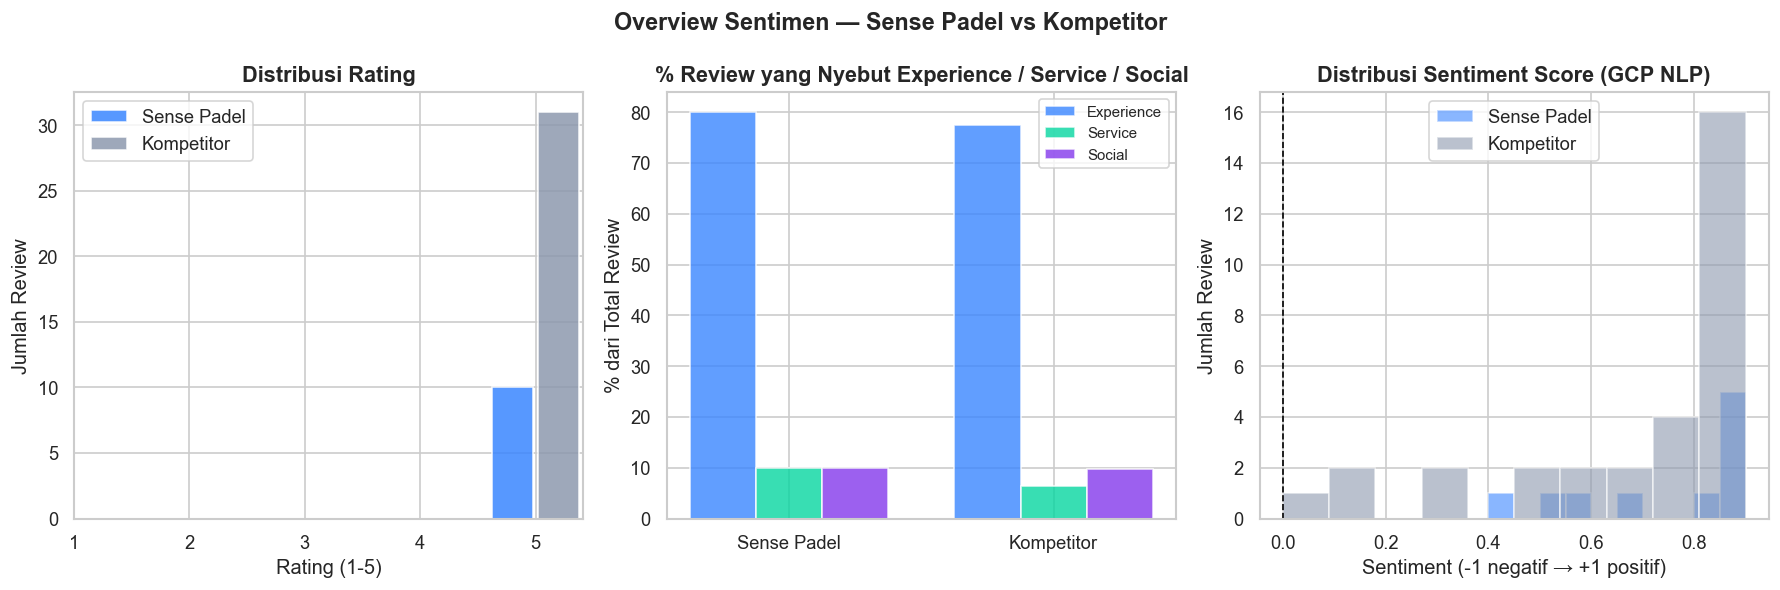

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Rating distribution: Sense Padel vs Kompetitor
ax1 = axes[0]
for data, label, color in [(df_sense, 'Sense Padel', BLUE), (df_comp, 'Kompetitor', GRAY)]:
    counts = data['rating'].value_counts().sort_index()
    ax1.bar(counts.index + (0.2 if label == 'Kompetitor' else -0.2),
            counts.values, width=0.35, label=label, color=color, alpha=0.85, edgecolor='white')
ax1.set_title('Distribusi Rating', fontweight='bold')
ax1.set_xlabel('Rating (1-5)')
ax1.set_ylabel('Jumlah Review')
ax1.set_xticks([1,2,3,4,5])
ax1.legend()

# Experience vs Service split
ax2 = axes[1]
for data, label, x_pos in [(df_sense, 'Sense', 0), (df_comp, 'Kompetitor', 1)]:
    exp_pct = (data['exp_score'] > 0).mean() * 100
    svc_pct = (data['svc_score'] > 0).mean() * 100
    soc_pct = (data['soc_score'] > 0).mean() * 100
    ax2.bar(x_pos - 0.25, exp_pct, width=0.25, color=BLUE, alpha=0.8, label='Experience' if x_pos == 0 else '')
    ax2.bar(x_pos,         svc_pct, width=0.25, color=GREEN, alpha=0.8, label='Service' if x_pos == 0 else '')
    ax2.bar(x_pos + 0.25,  soc_pct, width=0.25, color=PURPLE, alpha=0.8, label='Social' if x_pos == 0 else '')
ax2.set_title('% Review yang Nyebut Experience / Service / Social', fontweight='bold')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Sense Padel', 'Kompetitor'])
ax2.set_ylabel('% dari Total Review')
ax2.legend(fontsize=9)

# Sentiment distribution
ax3 = axes[2]
for data, label, color in [(df_sense, 'Sense Padel', BLUE), (df_comp, 'Kompetitor', GRAY)]:
    sent_data = data['sentiment_score'].dropna()
    if len(sent_data) > 1:
        ax3.hist(sent_data, bins=10, alpha=0.6, color=color, label=label, edgecolor='white')
ax3.axvline(0, color='black', linewidth=1, linestyle='--')
ax3.set_title('Distribusi Sentiment Score (GCP NLP)', fontweight='bold')
ax3.set_xlabel('Sentiment (-1 negatif → +1 positif)')
ax3.set_ylabel('Jumlah Review')
ax3.legend()

plt.suptitle('Overview Sentimen — Sense Padel vs Kompetitor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

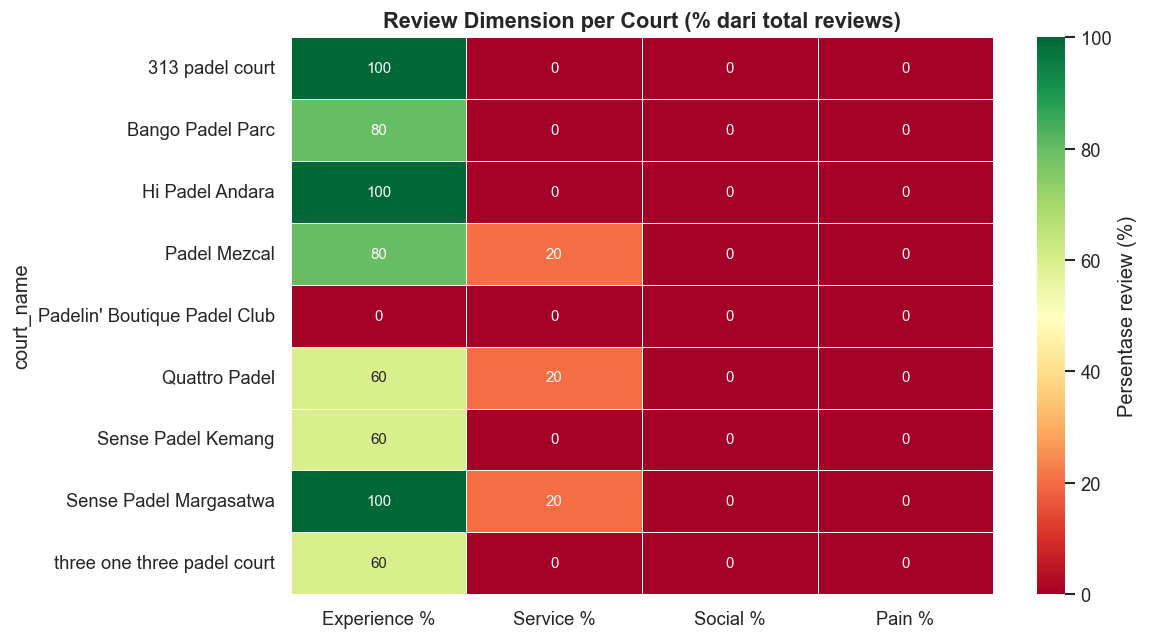

In [14]:
# Heatmap: dimensi per court
if df_sum is not None:
    heat_cols = ['pct_experience', 'pct_service', 'pct_social', 'pct_pain']
    heat_data = df_sum.set_index('court_name')[heat_cols].copy()
    heat_data.columns = ['Experience %', 'Service %', 'Social %', 'Pain %']

    fig, ax = plt.subplots(figsize=(10, max(4, len(heat_data) * 0.5 + 1)))
    sns.heatmap(heat_data, annot=True, fmt='.0f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0, vmax=100,
                cbar_kws={'label': 'Persentase review (%)'},
                annot_kws={'size': 9})
    ax.set_title('Review Dimension per Court (% dari total reviews)', fontweight='bold')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()
else:
    print('[!] Summary CSV not found — run scraper_reviews_pondoklabu.py')

In [15]:
# Competitor pain points — keyword frequency dari review negatif
PAIN_KW = [
    'kecewa', 'buruk', 'jelek', 'susah', 'lambat', 'mahal', 'kotor', 'penuh',
    'tidak ada', 'ngga ada', 'ga ada', 'kurang', 'jutek', 'tidak ramah',
    'trouble', 'rusak', 'bocor', 'panas', 'gelap', 'sempit',
    'booking susah', 'penuh terus', 'susah cari lawan', 'slow respon',
]

neg_comp = df_comp[df_comp['rating'] <= 3]
pain_counter = Counter()
for text in neg_comp['review_text'].str.lower():
    for kw in PAIN_KW:
        if kw in text:
            pain_counter[kw] += 1

top_pain = dict(pain_counter.most_common(12))

if top_pain:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(list(top_pain.keys()), list(top_pain.values()),
                   color=RED, edgecolor='white')
    ax.set_title('Pain Points Kompetitor — Celah Strategis Sense Padel\n(dari review bintang 1-3)',
                 fontweight='bold')
    ax.set_xlabel('Frekuensi Kemunculan')
    ax.invert_yaxis()
    for bar in bars:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                str(int(bar.get_width())), va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('[!] No pain keywords found. Possibly reviews are too positive or count is small.')

print('\nSample review negatif kompetitor (pain point evidence):')
neg_samples = neg_comp[neg_comp['pain_score'] > 0][['court_name','rating','review_text']].head(5)
for _, row in neg_samples.iterrows():
    print(f'  [{row["court_name"][:30]} | ⭐{row["rating"]}] "{row["review_text"][:150]}"')

[!] No pain keywords found. Possibly reviews are too positive or count is small.

Sample review negatif kompetitor (pain point evidence):


---
## Section 3: Social Connectivity & Community Moat Score

**Framework Community Moat:**

| Dimensi | Indikator | Bobot |
|---------|-----------|-------|
| Social Language | % review nyebut komunitas/teman/liga | 30% |
| Switching Cost | Rating tinggi + high review count (engagement proxy) | 25% |
| Liga/Event Signal | Keyword kompetisi, turnamen, ranking | 25% |
| Niche Alignment | Sinyal segmen khusus (business, ladies, beginner) | 20% |

In [16]:
# Social connectivity analysis
social_reviews = df_rev[df_rev['soc_score'] > 0].copy()
total_social = len(social_reviews)
social_pct   = total_social / len(df_rev) * 100 if len(df_rev) > 0 else 0

SOCIAL_KW_DETAIL = [
    ('teman baru / nemu lawan', ['teman', 'temen baru', 'nemu temen', 'lawan baru', 'cari lawan', 'partner']),
    ('komunitas / club',        ['komunitas', 'community', 'club', 'bergabung', 'join']),
    ('liga / turnamen',         ['liga', 'turnamen', 'kompetisi', 'ranking', 'ladder', 'event']),
    ('social / networking',     ['social', 'networking', 'bisnis', 'kolega', 'kenal', 'bareng']),
]

social_freq = {}
all_texts = df_rev['review_text'].str.lower()
for label, kws in SOCIAL_KW_DETAIL:
    count = sum(1 for text in all_texts for kw in kws if kw in text)
    social_freq[label] = count

print(f'Review dengan sinyal sosial: {total_social} / {len(df_rev)} ({social_pct:.1f}%)')
print()
for label, count in sorted(social_freq.items(), key=lambda x: -x[1]):
    bar = '█' * min(count * 2, 40)
    print(f'  {label:<35} {count:3d}  {bar}')

if social_pct > 30:
    maturity = 'MATURE — Komunitas sudah terbentuk organik'
    mat_color = GREEN
elif social_pct > 10:
    maturity = 'GROWING — Ada sinyal, perlu diperkuat'
    mat_color = AMBER
else:
    maturity = 'EARLY — Komunitas belum terbentuk. Ini peluang differensiasi'
    mat_color = RED
    
print(f'\nSocial Maturity: {maturity}')

Review dengan sinyal sosial: 4 / 41 (9.8%)

  komunitas / club                      3  ██████
  teman baru / nemu lawan               1  ██
  liga / turnamen                       1  ██
  social / networking                   0  

Social Maturity: EARLY — Komunitas belum terbentuk. Ini peluang differensiasi


In [17]:
# Hitung Community Moat Score per court
moat_scores = []

for court, group in df_rev.groupby('court_name'):
    # Dimensi 1: Social Language (0-30)
    soc_pct = (group['soc_score'] > 0).mean()
    d1 = min(soc_pct * 100, 30)

    # Dimensi 2: Engagement Proxy — avg rating × log(review_count) normalized (0-25)
    avg_rat   = group['rating'].mean() if not group['rating'].isna().all() else 0
    rev_count = df_courts[df_courts['name'].str.contains(court[:15], case=False, na=False)]['review_count'].values
    rev_count_n = float(rev_count[0]) if len(rev_count) > 0 and pd.notna(rev_count[0]) else 5
    d2 = min((avg_rat / 5) * math.log(max(rev_count_n, 1) + 1) / math.log(501) * 25, 25)

    # Dimensi 3: Liga / Event Signal (0-25)
    liga_kws  = ['liga', 'turnamen', 'kompetisi', 'ranking', 'ladder', 'event']
    liga_hits = sum(1 for t in group['review_text'].str.lower() for kw in liga_kws if kw in t)
    d3 = min(liga_hits / max(len(group), 1) * 100, 25)

    # Dimensi 4: Niche Alignment (0-20)
    niche_vals = group['niche_signal'].value_counts()
    d4 = 20 if (len(niche_vals) > 0 and niche_vals.index[0] != 'none') else 0

    total_score = d1 + d2 + d3 + d4

    moat_scores.append({
        'court_name':       court,
        'is_sense_padel':   'Sense' in court,
        'D1_social':        round(d1, 1),
        'D2_engagement':    round(d2, 1),
        'D3_liga':          round(d3, 1),
        'D4_niche':         round(d4, 1),
        'moat_score':       round(total_score, 1),
    })

df_moat = pd.DataFrame(moat_scores).sort_values('moat_score', ascending=False)
print('Community Moat Scores (max 100):')
print(df_moat.to_string(index=False))

Community Moat Scores (max 100):
                  court_name  is_sense_padel  D1_social  D2_engagement  D3_liga  D4_niche  moat_score
               Quattro Padel           False       20.0           19.1     20.0         0        59.1
             Hi Padel Andara           False       20.0           19.8      0.0         0        39.8
 three one three padel court           False       20.0           16.7      0.0         0        36.7
      Sense Padel Margasatwa            True       20.0           15.7      0.0         0        35.7
          Sense Padel Kemang            True        0.0           19.4      0.0         0        19.4
             313 padel court           False        0.0           14.5      0.0         0        14.5
            Bango Padel Parc           False        0.0           13.4      0.0         0        13.4
                Padel Mezcal           False        0.0           13.4      0.0         0        13.4
Padelin' Boutique Padel Club           False     

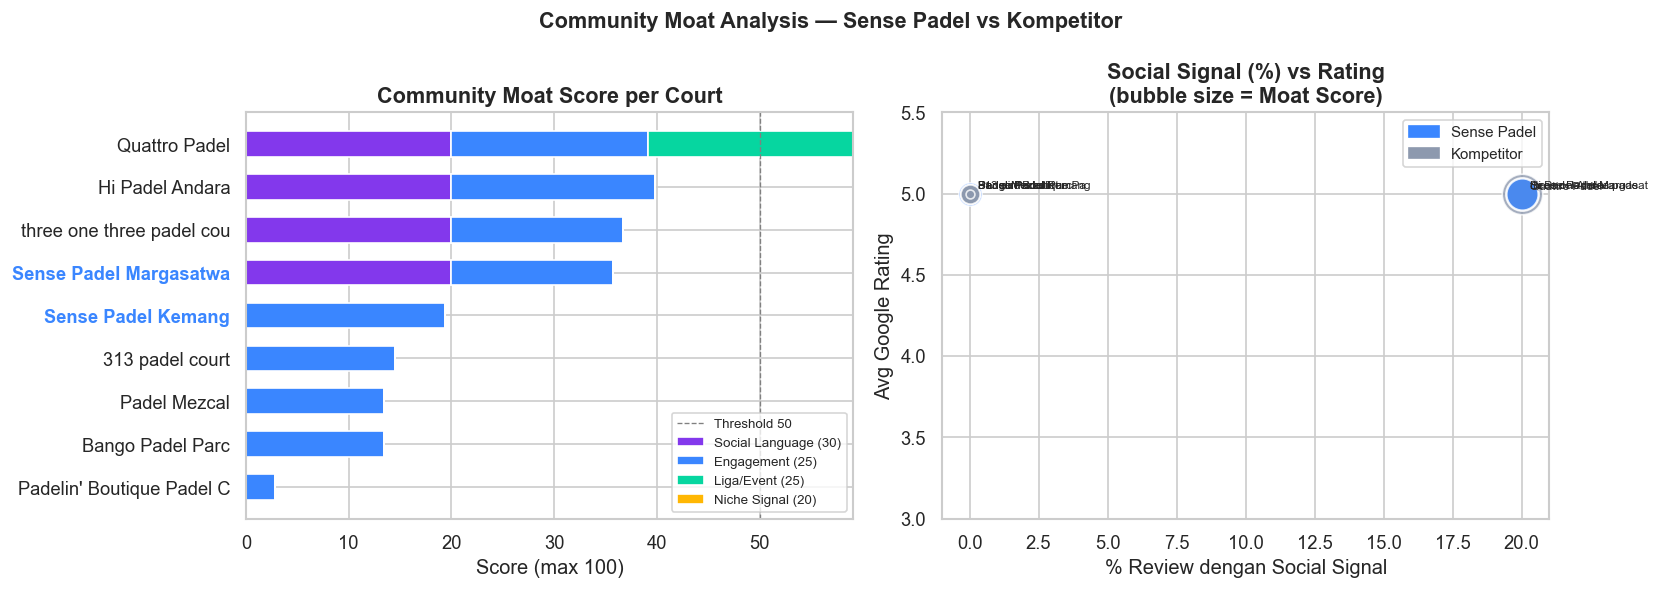

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Stacked bar moat score
ax1 = axes[0]
moat_sorted = df_moat.sort_values('moat_score')
court_labels = [c[:25] for c in moat_sorted['court_name']]

bar_colors = {
    'D1_social':     PURPLE,
    'D2_engagement': BLUE,
    'D3_liga':       GREEN,
    'D4_niche':      AMBER,
}
dims_labels = {
    'D1_social':     'Social Language (30)',
    'D2_engagement': 'Engagement (25)',
    'D3_liga':       'Liga/Event (25)',
    'D4_niche':      'Niche Signal (20)',
}
bottom = np.zeros(len(moat_sorted))
for col, color in bar_colors.items():
    vals = moat_sorted[col].values
    ax1.barh(court_labels, vals, left=bottom, color=color,
             label=dims_labels[col], edgecolor='white', height=0.6)
    bottom += vals

# Highlight Sense Padel
sense_idx = [i for i, n in enumerate(moat_sorted['court_name']) if 'Sense' in n]
for idx in sense_idx:
    ax1.get_yticklabels()[idx].set_color(BLUE)
    ax1.get_yticklabels()[idx].set_fontweight('bold')

ax1.set_title('Community Moat Score per Court', fontweight='bold')
ax1.set_xlabel('Score (max 100)')
ax1.axvline(50, color='gray', linewidth=0.8, linestyle='--', label='Threshold 50')
ax1.legend(fontsize=8, loc='lower right')

# Plot 2: Social % vs Rating bubble
ax2 = axes[1]
for _, row in df_moat.iterrows():
    court_data = df_rev[df_rev['court_name'] == row['court_name']]
    soc_pct   = (court_data['soc_score'] > 0).mean() * 100
    avg_rating = court_data['rating'].mean()
    size = row['moat_score'] * 10
    color = BLUE if row['is_sense_padel'] else GRAY
    ax2.scatter(soc_pct, avg_rating, s=size, color=color, alpha=0.8, edgecolors='white', linewidth=1)
    ax2.annotate(row['court_name'][:20], (soc_pct, avg_rating),
                 textcoords='offset points', xytext=(5, 3), fontsize=7)

ax2.set_title('Social Signal (%) vs Rating\n(bubble size = Moat Score)', fontweight='bold')
ax2.set_xlabel('% Review dengan Social Signal')
ax2.set_ylabel('Avg Google Rating')
ax2.set_ylim(3, 5.5)

sense_patch  = mpatches.Patch(color=BLUE, label='Sense Padel')
comp_patch   = mpatches.Patch(color=GRAY, label='Kompetitor')
ax2.legend(handles=[sense_patch, comp_patch], fontsize=9)

plt.suptitle('Community Moat Analysis — Sense Padel vs Kompetitor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4: Niche Strategy Matrix

Berdasarkan density + moat score, evaluasi 3 niche option:

| Niche | Trigger | Switching Cost |
|-------|---------|----------------|
| **Business Networking** | Market padat + upper-middle segment | Tinggi (relasi bisnis) |
| **Ladies Community** | Gap pelanggan wanita + safety | Tinggi (trust network) |
| **Beginner Academy** | Market muda + growth play | Medium (skill progression) |

In [19]:
NICHE_SIGNALS_KW = {
    'Business\nNetworking': ['bisnis', 'kantor', 'networking', 'client', 'kolega',
                              'rekan kerja', 'profesional', 'corporate', 'office'],
    'Ladies\nCommunity':    ['ladies', 'wanita', 'perempuan', 'ibu', 'cewek',
                              'ladies day', 'girls', 'mama', 'arisan'],
    'Beginner\nAcademy':    ['pemula', 'baru belajar', 'newbie', 'belajar',
                              'beginner', 'latihan', 'coach', 'kursus', 'les'],
    'Liga &\nKompetisi':    ['liga', 'turnamen', 'kompetisi', 'ranking', 'ladder',
                              'event', 'bracket', 'juara'],
}

all_texts_lower = df_rev['review_text'].str.lower().tolist()
niche_scores = {}
niche_examples = {}

for niche, kws in NICHE_SIGNALS_KW.items():
    hits = [(kw, t) for t in all_texts_lower for kw in kws if kw in t]
    niche_scores[niche] = len(hits)
    niche_examples[niche] = [h[0] for h in hits[:5]]

# Niche opportunity matrix
# Opportunity = market signal strength × gap from competitors
# For simplicity: signal strength from reviews

sense_texts = df_sense['review_text'].str.lower().tolist()
comp_texts  = df_comp['review_text'].str.lower().tolist()

niche_opportunity = {}
for niche, kws in NICHE_SIGNALS_KW.items():
    sense_hits = sum(1 for t in sense_texts for kw in kws if kw in t)
    comp_hits  = sum(1 for t in comp_texts  for kw in kws if kw in t)
    # Gap: kompetitor sudah serve niche ini atau belum?
    comp_coverage = comp_hits / max(len(comp_texts), 1) * 100
    demand_signal = (sense_hits + comp_hits) / max(len(all_texts_lower), 1) * 100
    gap = max(0, demand_signal - comp_coverage / 2)
    niche_opportunity[niche] = {
        'demand_signal': round(demand_signal, 1),
        'comp_coverage': round(comp_coverage, 1),
        'gap_score':     round(gap, 1),
    }

df_niche = pd.DataFrame(niche_opportunity).T
print('Niche Opportunity Matrix:')
print(df_niche.to_string())

best_niche = df_niche['gap_score'].idxmax()
print(f'\nBest niche opportunity: {best_niche}')

Niche Opportunity Matrix:
                      demand_signal  comp_coverage  gap_score
Business\nNetworking            0.0            0.0        0.0
Ladies\nCommunity               0.0            0.0        0.0
Beginner\nAcademy               2.4            0.0        2.4
Liga &\nKompetisi               2.4            3.2        0.8

Best niche opportunity: Beginner
Academy


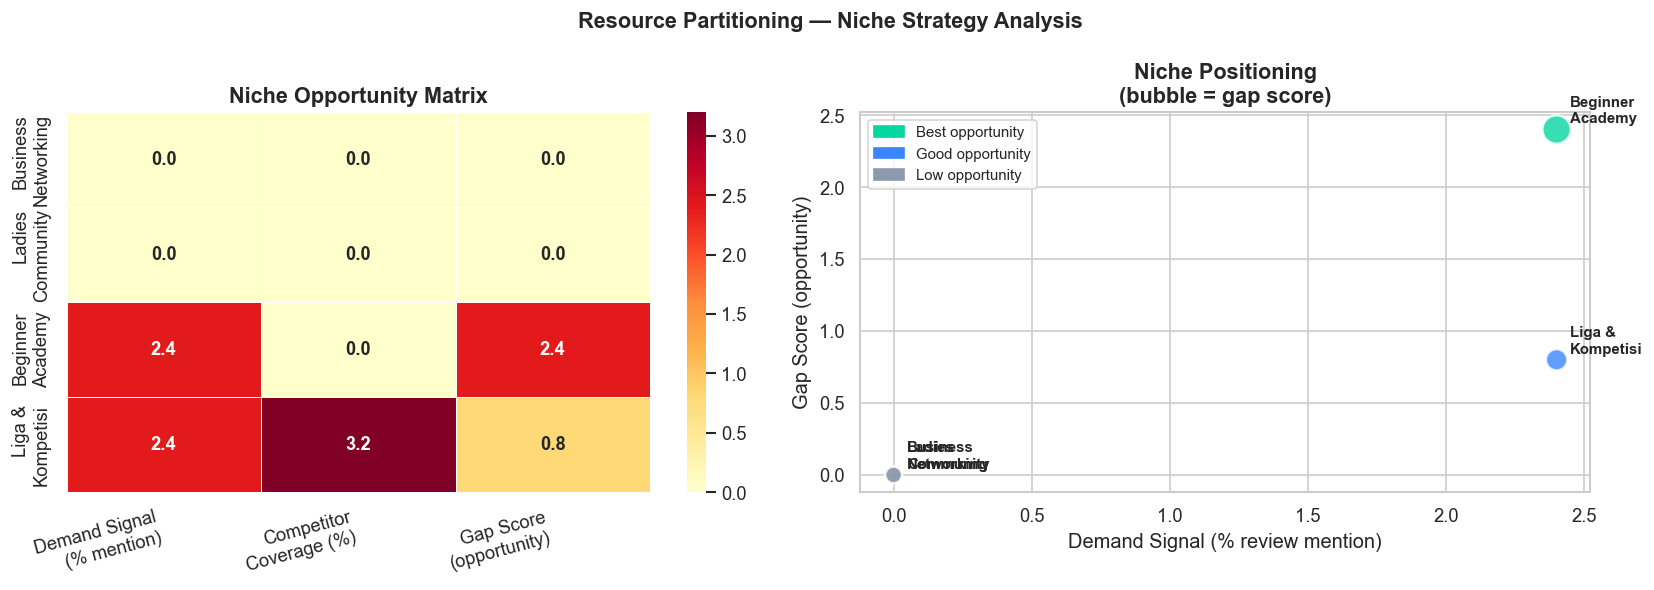

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Niche signal heatmap
ax1 = axes[0]
heat_niche = df_niche[['demand_signal', 'comp_coverage', 'gap_score']]
heat_niche.columns = ['Demand Signal\n(% mention)', 'Competitor\nCoverage (%)', 'Gap Score\n(opportunity)']
sns.heatmap(heat_niche, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax1, vmin=0,
            annot_kws={'size': 11, 'weight': 'bold'})
ax1.set_title('Niche Opportunity Matrix', fontweight='bold')
ax1.set_xlabel('')
plt.setp(ax1.get_xticklabels(), rotation=15, ha='right')

# Plot 2: Resource Partitioning diagram
ax2 = axes[1]
niches = list(df_niche.index)
gaps   = df_niche['gap_score'].values
demands = df_niche['demand_signal'].values

bubble_colors = [GREEN if g == gaps.max() else BLUE if g > np.median(gaps) else GRAY for g in gaps]
sc = ax2.scatter(demands, gaps, s=[g * 80 + 100 for g in gaps],
                 c=bubble_colors, alpha=0.8, edgecolors='white', linewidth=1.5)
for i, niche in enumerate(niches):
    ax2.annotate(niche, (demands[i], gaps[i]),
                 textcoords='offset points', xytext=(8, 4), fontsize=9, fontweight='bold')

ax2.set_xlabel('Demand Signal (% review mention)')
ax2.set_ylabel('Gap Score (opportunity)')
ax2.set_title('Niche Positioning\n(bubble = gap score)', fontweight='bold')

green_patch = mpatches.Patch(color=GREEN, label='Best opportunity')
blue_patch  = mpatches.Patch(color=BLUE,  label='Good opportunity')
gray_patch  = mpatches.Patch(color=GRAY,  label='Low opportunity')
ax2.legend(handles=[green_patch, blue_patch, gray_patch], fontsize=9)

plt.suptitle('Resource Partitioning — Niche Strategy Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 5: Executive Summary for Owner

> *Analisis ini bukan tentang "di mana lahan kosong" tapi tentang "gimana Sense Padel bertahan dan tumbuh saat hype padel mati".*

In [21]:
# Compute final metrics for summary
sense_avg_rating = df_sense['rating'].mean() if len(df_sense) > 0 else 'N/A'
comp_avg_rating  = df_comp['rating'].mean()  if len(df_comp) > 0 else 'N/A'
sense_social_pct = (df_sense['soc_score'] > 0).mean() * 100 if len(df_sense) > 0 else 0
comp_social_pct  = (df_comp['soc_score'] > 0).mean() * 100  if len(df_comp) > 0 else 0

# Spesifik ke Margasatwa (= Pondok Labu), fallback ke avg Sense brand
margasatwa_moat = df_moat[df_moat['court_name'].str.contains('Margasatwa', case=False, na=False)]['moat_score'].values
sense_moat_score = float(margasatwa_moat[0]) if len(margasatwa_moat) > 0 else df_moat[df_moat['is_sense_padel']]['moat_score'].mean()
market_avg_moat  = df_moat[~df_moat['is_sense_padel']]['moat_score'].mean()

density_status_label = density_label  # from Section 1
best_niche_clean = best_niche.replace('\n', ' ')

# Final strategic recommendation logic
if n_3km > 6:
    strategy = 'NICHE + COMMUNITY — Market jenuh. Pilih satu niche, build community di dalamnya.'
elif n_3km >= 3:
    strategy = 'COMMUNITY FIRST — Pesaing ada, tapi celah komunitas masih terbuka. Build moat sebelum terlambat.'
else:
    strategy = 'GROW + COMMUNITY — Market terbuka. Scale dulu, tapi mulai build community sekarang.'

print(f'''
{'='*68}
  EXECUTIVE SUMMARY — SENSE PADEL PONDOK LABU (Margasatwa)
  Pertanyaan: "Gimana supaya nggak kena hype decay?"
{'='*68}

─── 1. KONDISI PASAR (Density) ──────────────────────────────────
  Status: {density_status_label}
  Court competitor dalam 3km (≈10 mnt): {n_3km}
  Court competitor dalam 5km (≈15 mnt): {n_5km}
  → {'Margin akan tertekan. Niche bukan pilihan, tapi keharusan.' if n_3km > 6
     else 'Ada ruang, tapi perlu diferensiasi segera.' if n_3km >= 3
     else 'Ruang masih terbuka. Window of opportunity untuk build first-mover.'}

─── 2. APA YANG DIBELI CUSTOMER ─────────────────────────────────
  Sense Padel  → Experience reviews: {(df_sense['exp_score'] > 0).mean()*100:.0f}%
                  Service reviews   : {(df_sense['svc_score'] > 0).mean()*100:.0f}%
  Rata kompetitor → Experience : {(df_comp['exp_score'] > 0).mean()*100:.0f}%
                     Service   : {(df_comp['svc_score'] > 0).mean()*100:.0f}%
  → {'Customer saat ini beli experience (fasilitas). Service adalah medan diferensiasi.' if (df_comp['exp_score'] > 0).mean() > (df_comp['svc_score'] > 0).mean()
     else 'Customer sudah tuntut service quality. Fasilitas alone tidak cukup.'}

─── 3. SINYAL KOMUNITAS (Moat Readiness) ────────────────────────
  Sense Padel Margasatwa Moat Score : {sense_moat_score:.1f} / 100
  Rata-rata kompetitor              : {market_avg_moat:.1f} / 100
  Social review (Sense Padel)       : {sense_social_pct:.0f}%
  Social review (kompetitor)        : {comp_social_pct:.0f}%
  → {'Sense Padel UNGGUL dalam social signal. Pertahankan dan formalize komunitas.' if sense_moat_score > market_avg_moat
     else 'Kompetitor sudah punya community head start. Sense Padel perlu bergerak cepat.'}

─── 4. NICHE TERBAIK ────────────────────────────────────────────
  Rekomendasi: {best_niche_clean}
  → Niche ini punya demand signal tapi belum di-serve optimal kompetitor.

─── 5. REKOMENDASI STRATEGI ─────────────────────────────────────
  {strategy}

  ACTION ITEMS untuk Owner:
  □ Buat sistem liga/ranking internal (switching cost emosional)
  □ Program "Member gets Member" — viral loop organik
  □ Monthly event bertema niche pilihan ({best_niche_clean})
  □ Dedicated WhatsApp group per skill level (beginner/intermediate/advanced)
  □ Track social metrics: berapa % member aktif datang lebih dari 2x/bulan?

─── 6. METRIK KEBERHASILAN (3 bulan) ────────────────────────────
  → Member retention rate > 60% (datang lagi dalam 30 hari)
  → Social review % naik dari {sense_social_pct:.0f}% → 20%+ (nyebut komunitas/teman)
  → Minimum 1 liga/event per bulan dengan 20+ peserta
  → Community Moat Score > 60 (saat ini: {sense_moat_score:.1f})

{'='*68}
  INTINYA: Bangunlah komunitas, bukan cuma nyediain fasilitas.
  Member yang punya teman di Sense Padel tidak akan pindah —
  karena mereka bukan cuma pindah lapangan, tapi kehilangan teman.
{'='*68}
''')


  EXECUTIVE SUMMARY — SENSE PADEL PONDOK LABU (Margasatwa)
  Pertanyaan: "Gimana supaya nggak kena hype decay?"

─── 1. KONDISI PASAR (Density) ──────────────────────────────────
  Status: MERAH — Sangat Padat
  Court competitor dalam 3km (≈10 mnt): 41
  Court competitor dalam 5km (≈15 mnt): 86
  → Margin akan tertekan. Niche bukan pilihan, tapi keharusan.

─── 2. APA YANG DIBELI CUSTOMER ─────────────────────────────────
  Sense Padel  → Experience reviews: 80%
                  Service reviews   : 10%
  Rata kompetitor → Experience : 77%
                     Service   : 6%
  → Customer saat ini beli experience (fasilitas). Service adalah medan diferensiasi.

─── 3. SINYAL KOMUNITAS (Moat Readiness) ────────────────────────
  Sense Padel Margasatwa Moat Score : 35.7 / 100
  Rata-rata kompetitor              : 25.7 / 100
  Social review (Sense Padel)       : 10%
  Social review (kompetitor)        : 10%
  → Sense Padel UNGGUL dalam social signal. Pertahankan dan formalize komunitas.



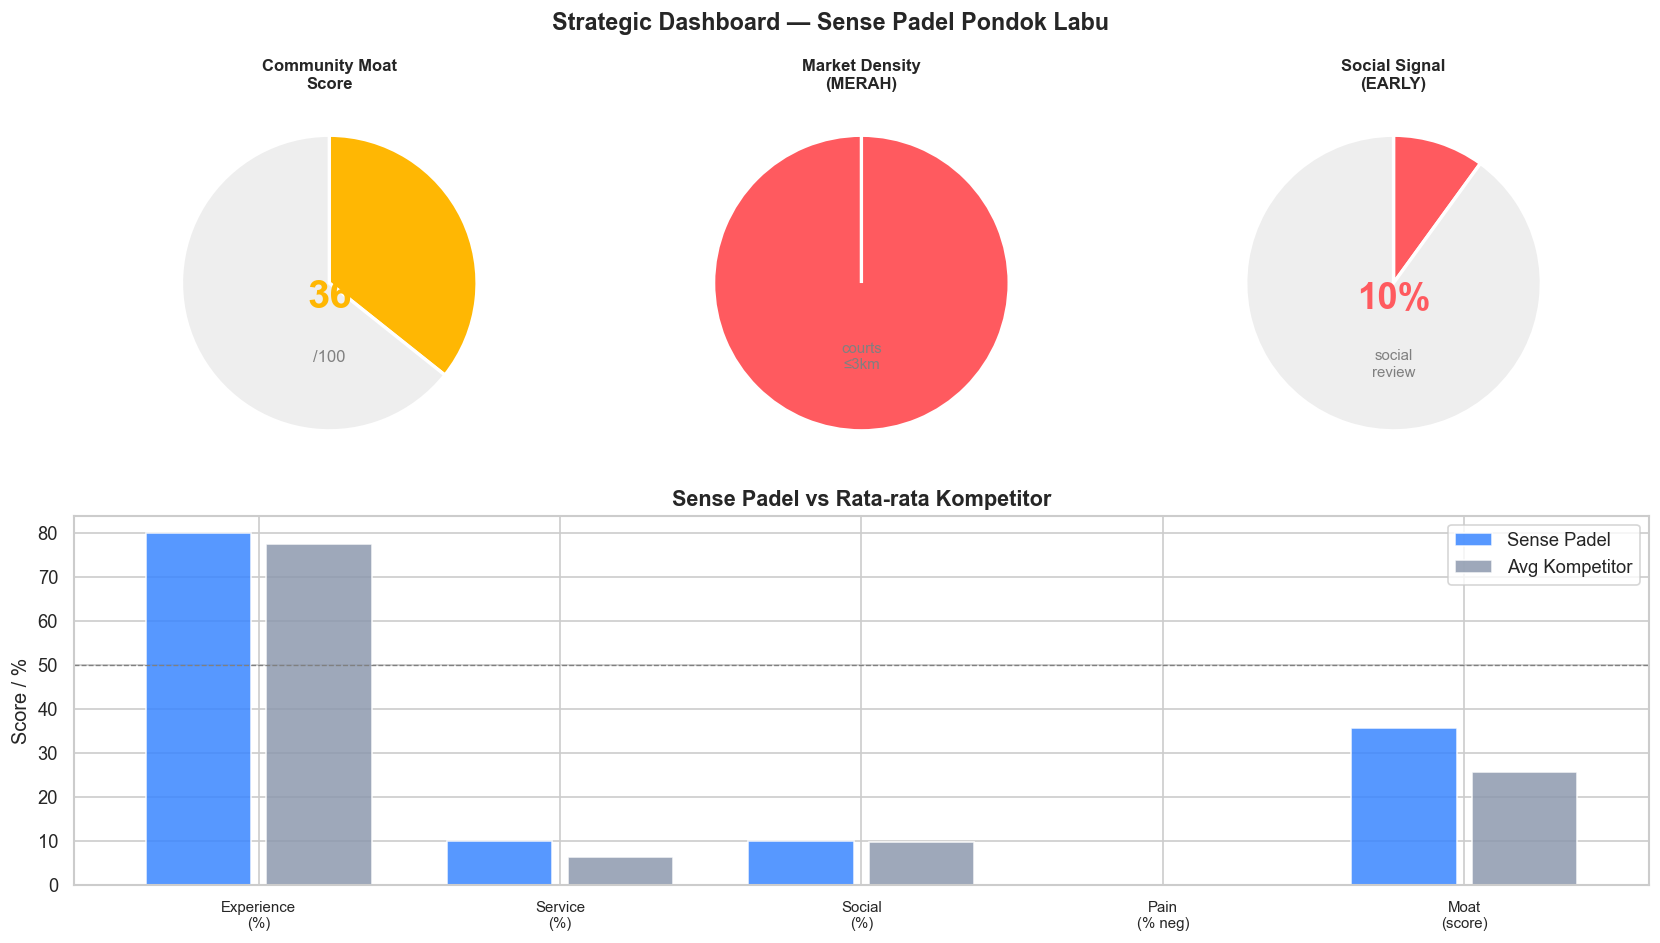


Dashboard saved: output/strategic_dashboard_pondoklabu.png


In [22]:
# Final summary dashboard
fig = plt.figure(figsize=(14, 8))

# Moat score gauge
ax1 = fig.add_subplot(2, 3, 1)
score_val = float(str(sense_moat_score)) if sense_moat_score != 'N/A' else 0
gauge_color = GREEN if score_val >= 60 else AMBER if score_val >= 35 else RED
ax1.pie([score_val, 100 - score_val], colors=[gauge_color, '#EEEEEE'],
        startangle=90, counterclock=False,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
ax1.text(0, -0.1, f'{score_val:.0f}', ha='center', va='center',
         fontsize=24, fontweight='bold', color=gauge_color)
ax1.text(0, -0.5, '/100', ha='center', va='center', fontsize=10, color='gray')
ax1.set_title('Community Moat\nScore', fontweight='bold', fontsize=10)

# Density indicator
ax2 = fig.add_subplot(2, 3, 2)
density_val = min(n_3km / 10 * 100, 100)
den_color = RED if n_3km > 6 else AMBER if n_3km >= 3 else GREEN
ax2.pie([density_val, 100 - density_val], colors=[den_color, '#EEEEEE'],
        startangle=90, counterclock=False,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
ax2.text(0, -0.1, str(n_3km), ha='center', va='center',
         fontsize=24, fontweight='bold', color=den_color)
ax2.text(0, -0.5, 'courts\n≤3km', ha='center', va='center', fontsize=9, color='gray')
ax2.set_title(f'Market Density\n({density_label.split("—")[0].strip()})', fontweight='bold', fontsize=10)

# Social signal
ax3 = fig.add_subplot(2, 3, 3)
soc_color = GREEN if sense_social_pct > 30 else AMBER if sense_social_pct > 10 else RED
ax3.pie([sense_social_pct, 100 - sense_social_pct], colors=[soc_color, '#EEEEEE'],
        startangle=90, counterclock=False,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
ax3.text(0, -0.1, f'{sense_social_pct:.0f}%', ha='center', va='center',
         fontsize=22, fontweight='bold', color=soc_color)
ax3.text(0, -0.55, 'social\nreview', ha='center', va='center', fontsize=9, color='gray')
ax3.set_title(f'Social Signal\n({maturity.split("—")[0].strip()})', fontweight='bold', fontsize=10)

# Radar: Sense Padel dimensions
ax4 = fig.add_subplot(2, 3, (4, 6))
exp_pct_s = (df_sense['exp_score'] > 0).mean() * 100
svc_pct_s = (df_sense['svc_score'] > 0).mean() * 100
soc_pct_s = (df_sense['soc_score'] > 0).mean() * 100
pain_pct_s = (df_sense['pain_score'] > 0).mean() * 100
moat_pct_s = float(str(sense_moat_score)) if sense_moat_score != 'N/A' else 0

exp_pct_c = (df_comp['exp_score'] > 0).mean() * 100
svc_pct_c = (df_comp['svc_score'] > 0).mean() * 100
soc_pct_c = (df_comp['soc_score'] > 0).mean() * 100
pain_pct_c = (df_comp['pain_score'] > 0).mean() * 100
moat_pct_c = market_avg_moat

cats = ['Experience\n(%)', 'Service\n(%)', 'Social\n(%)', 'Pain\n(% neg)', 'Moat\n(score)']
sense_vals = [exp_pct_s, svc_pct_s, soc_pct_s, pain_pct_s, moat_pct_s]
comp_vals  = [exp_pct_c, svc_pct_c, soc_pct_c, pain_pct_c, moat_pct_c]

x = np.arange(len(cats))
ax4.bar(x - 0.2, sense_vals, width=0.35, color=BLUE, alpha=0.85, label='Sense Padel', edgecolor='white')
ax4.bar(x + 0.2, comp_vals,  width=0.35, color=GRAY, alpha=0.85, label='Avg Kompetitor', edgecolor='white')
ax4.set_xticks(x)
ax4.set_xticklabels(cats, fontsize=9)
ax4.set_ylabel('Score / %')
ax4.set_title('Sense Padel vs Rata-rata Kompetitor', fontweight='bold')
ax4.legend()
ax4.axhline(50, color='gray', linewidth=0.8, linestyle='--')

fig.suptitle('Strategic Dashboard — Sense Padel Pondok Labu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'strategic_dashboard_pondoklabu.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDashboard saved: output/strategic_dashboard_pondoklabu.png')